# Data engineering

In this notebook we will take the mendeley dataset from “Steam Games Dataset: Player count history, Price history and data about games”, Wannigamage, Barlow, Lakshika & Kasmarik (UNSW Canberra), 2020. DOI 10.17632/ycy3sy3vj2.1, CC BY 4.0. https://data.mendeley.com/datasets/ycy3sy3vj2/1, and process it into a form that is useful for our model. Starting with just two input features for simplicity:
- A number indicating the start of a time series (e.g. 1st of Jan is denoted 0)
- The average player count per day over 90 consecutive days.

Let's load some sample data and see how we can do this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
raw_player_counts = pd.read_csv("../data/mendeley/PlayerCountHistoryPart1/10.csv")
print(raw_player_counts.head())
print(raw_player_counts.info())


               Time  Playercount
0  2017-12-14 00:00       8900.0
1  2017-12-14 00:05       8726.0
2  2017-12-14 00:10       8517.0
3  2017-12-14 00:15       8337.0
4  2017-12-14 00:20       8150.0
<class 'pandas.DataFrame'>
RangeIndex: 280224 entries, 0 to 280223
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Time         280224 non-null  str    
 1   Playercount  278237 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.3 MB
None


There are some null playercount values so we choose to drop these entirely.

In [3]:
player_counts = raw_player_counts.dropna(subset=["Playercount"])

We notice that this gives player counts every five minutes. This level of granularity isn't necessary for our model so we'd like to convert this into an average daily playercount. To do this we have to group columns by day and then take the mean.

In [4]:
player_counts["Time"] = player_counts["Time"].str[:10]
player_counts.head()

,Time,Playercount
0,2017-12-14,8900.0
1,2017-12-14,8726.0
2,2017-12-14,8517.0
3,2017-12-14,8337.0
4,2017-12-14,8150.0


In [ ]:
# groupby creates a lazy object - not a dataframe. Must apply mean() aggregation onto it to get a dataframe.
# set as_index to False to prevent "Time" becoming an index
avg_players = player_counts.groupby("Time", as_index=False).mean()
avg_players.head()

,Time,Playercount
0,2017-12-14,12046.159722
1,2017-12-15,12659.024306
2,2017-12-16,14011.180556
3,2017-12-17,14501.802083
4,2017-12-18,12614.819444


Let's try to plot this data now. For this, having the time as a datetime object is better than a string so first convert.

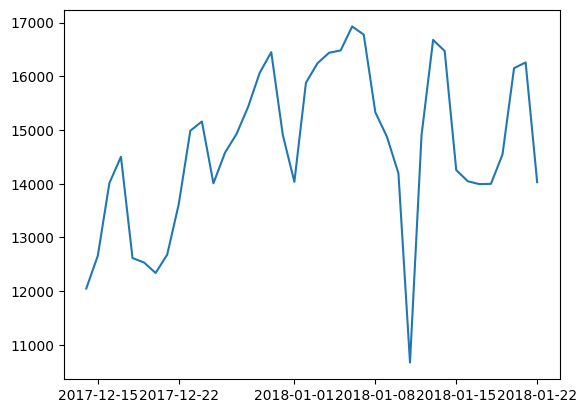

In [19]:
avg_players["Time"] = pd.to_datetime(avg_players["Time"])
window_size = 40
plt.plot(avg_players["Time"].iloc[:window_size], avg_players["Playercount"][:window_size])